In [7]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
import torchvision

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else
                      "cpu")
device


device(type='mps')

In [9]:
data_dir = "./sample_computer_vision"  # 필요하면 절대경로로 변경

# 만약 검증 폴더 이름이 "val"이 아니라 "valid" 라면 여기서 맞춰주세요.
image_datasets = {
    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        transforms.Compose(
            [
                transforms.RandomResizedCrop(224) if x == "train" else transforms.Resize(256),
                transforms.RandomHorizontalFlip() if x == "train" else transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225]),
            ]
        )
    )
    for x in ["train", "val"]
}

dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x],
                                   batch_size=8, shuffle=True, num_workers=2)
    for x in ["train", "val"]
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets["train"].classes

dataset_sizes, class_names


({'train': 1002, 'val': 200}, ['cats', 'dogs'])

In [10]:
def imshow(inp, title=None):
    """Tensor -> 이미지로 보여주기"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis("off")

# train 데이터에서 한 배치 뽑기
inputs, classes_idx = next(iter(dataloaders["train"]))

# 그리기
out = torchvision.utils.make_grid(inputs)  # <- 이 줄 때문에 아래 임포트 추가 필요


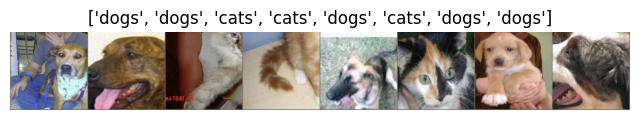

In [11]:
plt.figure(figsize=(8, 8))
imshow(out, title=[class_names[x] for x in classes_idx])
plt.show()


In [12]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# 모든 파라미터를 학습시킵니다. (튜토리얼 버전)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 7epoch마다 lr 0.1로 감소
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


In [15]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        # 각 epoch마다 train/val 수행
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # 미니배치 단위
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # forward
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize (train일 때만)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

            # best model 저장
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()  # 줄바꿈

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    # best 모델 로드
    model.load_state_dict(best_model_wts)
    return model


In [16]:
model = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=10)


Epoch 1/10
------------------------------
train Loss: 0.2972  Acc: 0.8752
val Loss: 0.1609  Acc: 0.9550

Epoch 2/10
------------------------------
train Loss: 0.2141  Acc: 0.9142
val Loss: 0.1118  Acc: 0.9700

Epoch 3/10
------------------------------
train Loss: 0.2168  Acc: 0.9022
val Loss: 0.0962  Acc: 0.9800

Epoch 4/10
------------------------------
train Loss: 0.1885  Acc: 0.9122
val Loss: 0.1417  Acc: 0.9600

Epoch 5/10
------------------------------
train Loss: 0.2410  Acc: 0.9062
val Loss: 0.0905  Acc: 0.9800

Epoch 6/10
------------------------------
train Loss: 0.2058  Acc: 0.9132
val Loss: 0.1350  Acc: 0.9650

Epoch 7/10
------------------------------
train Loss: 0.2188  Acc: 0.9112
val Loss: 0.1153  Acc: 0.9750

Epoch 8/10
------------------------------
train Loss: 0.1572  Acc: 0.9381
val Loss: 0.1163  Acc: 0.9750

Epoch 9/10
------------------------------
train Loss: 0.1560  Acc: 0.9311
val Loss: 0.1144  Acc: 0.9750

Epoch 10/10
------------------------------
train Loss: 

In [17]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(10, 10))

    with torch.no_grad():
        for inputs, labels in dataloaders["val"]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                plt.subplot(int(np.ceil(num_images/3)), 3, images_so_far)
                plt.tight_layout()
                img = inputs[j].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                title = f"pred: {class_names[preds[j]]}\nlabel: {class_names[labels[j]]}"
                color = "green" if preds[j] == labels[j] else "red"
                plt.title(title, color=color, fontsize=9)
                plt.axis("off")

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


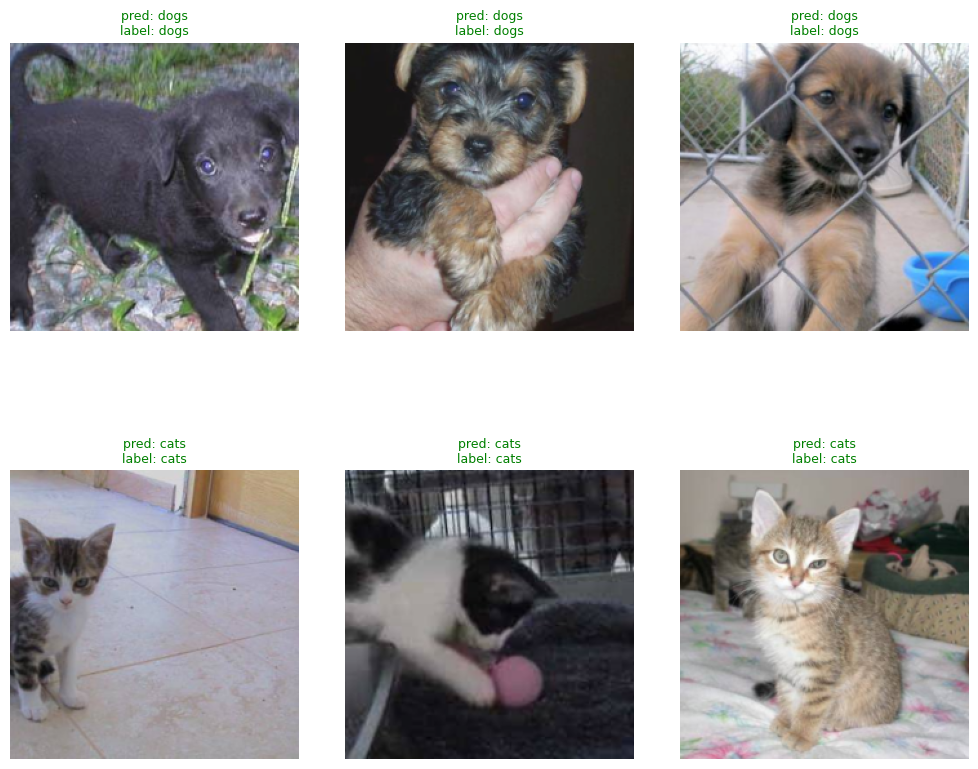

In [18]:
visualize_model(model, num_images=6)
plt.show()
